<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/H2O_Quantum_Chemistry_Qiskit_Notebook_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💧 Kuantum Kimya: H₂O Molekül Simülasyonu
## Qiskit Nature + PySCF + VQE (Uçtan Uca Colab)

**Amaç:** Su molekülünün elektronik taban durumu enerjisini kuantum algoritması (VQE) ile tahmin etmek.

| Bölüm | İçerik |
|-------|--------|
| 1 | Kurulum |
| 2 | Elektronik yapı problemi nedir? |
| 3 | H₂ ısınma turu (küçük sistem) |
| 4 | H₂O geometrisi ve PySCF sürücüsü |
| 5 | Active space / qubit mapping |
| 6 | VQE ile taban durumu |
| 7 | Klasik referans ile karşılaştırma |
| 8 | Yorum, sınırlar, ödevler |

> H₂O tam uzayda çok qubit ister. Eğitim için **active space** ile boyut küçültülür; yine de gerçek Qiskit Nature iş akışını gösterir.


## 1. Ortam Kurulumu


In [ ]:
import sys
print(f"Python: {sys.version.split()[0]}")

!pip install -q --upgrade pip
!pip install -q qiskit qiskit-aer qiskit-algorithms qiskit-nature
!pip install -q pyscf numpy matplotlib pandas

print("✅ Kurulum tamam.")


Python: 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.1 MB/s eta 0:00:00
✅ Kurulum tamam.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import SLSQP, COBYLA
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver, VQE
from qiskit.circuit.library import TwoLocal

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper, ParityMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer, FreezeCoreTransformer

# Estimator: Qiskit 1.x/2.x uyumu
def get_estimator():
    try:
        from qiskit.primitives import StatevectorEstimator
        print("✅ Estimator: StatevectorEstimator")
        return StatevectorEstimator()
    except ImportError:
        pass
    try:
        from qiskit_aer.primitives import Estimator as AerEstimator
        print("✅ Estimator: qiskit_aer.primitives.Estimator")
        return AerEstimator()
    except ImportError:
        pass
    try:
        from qiskit.primitives import Estimator
        print("✅ Estimator: qiskit.primitives.Estimator (eski)")
        return Estimator()
    except ImportError as e:
        raise ImportError(
            "Estimator bulunamadı. Deneyin:\n"
            "!pip install -U qiskit qiskit-aer qiskit-algorithms qiskit-nature"
        ) from e

estimator = get_estimator()
print("✅ Kütüphaneler yüklendi.")


✅ Estimator: StatevectorEstimator
✅ Kütüphaneler yüklendi.


## 2. Elektronik Yapı Problemi (Kısa Teori)

Moleküler Hamiltonyen (Born–Oppenheimer, ikinci kuantizasyon):

$$
\hat{H} = \sum_{pq} h_{pq} a_p^\dagger a_q + \tfrac{1}{2}\sum_{pqrs} h_{pqrs} a_p^\dagger a_q^\dagger a_r a_s
$$

- $h_{pq}$, $h_{pqrs}$: PySCF gibi klasik programlardan gelen integraller
- Fermiyon → qubit: **Jordan–Wigner**, **Parity**, Bravyi–Kitaev
- Taban durumu: $\min_{\theta}\langle\psi(\theta)|\hat{H}|\psi(\theta)\rangle$ → **VQE**

**H₂O:** 10 elektron, minimal basis’te bile onlarca spin-orbital → active space şart.


## 3. Isınma: H₂ Molekülü (Tam İş Akışı, Az Qubit)

H₂ ile driver → mapper → klasik exact → VQE adımlarını doğrulayın.


In [ ]:
# H2: 0.735 Angstrom, STO-3G
driver_h2 = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)
problem_h2 = driver_h2.run()
print("H₂ parçacık sayısı:", problem_h2.num_particles)
print("H₂ uzaysal orbital:", problem_h2.num_spatial_orbitals)

mapper = JordanWignerMapper()
algo_exact = GroundStateEigensolver(mapper, NumPyMinimumEigensolver())
result_h2_exact = algo_exact.solve(problem_h2)
print(f"\nH₂ taban durumu (exact diagonalization): {result_h2_exact.total_energies[0]:.6f} Ha")


H₂ parçacık sayısı: (1, 1)
H₂ uzaysal orbital: 2

H₂ taban durumu (exact diagonalization): -1.137306 Ha


In [ ]:
# H2 VQE – UCCSD
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

ansatz_h2 = UCCSD(
    problem_h2.num_spatial_orbitals,
    problem_h2.num_particles,
    mapper,
    initial_state=HartreeFock(
        problem_h2.num_spatial_orbitals,
        problem_h2.num_particles,
        mapper,
    ),
)

optimizer = SLSQP(maxiter=80)
vqe = VQE(estimator, ansatz_h2, optimizer)
solver_h2 = GroundStateEigensolver(mapper, vqe)

print("⏳ H₂ VQE çalışıyor...")
result_h2_vqe = solver_h2.solve(problem_h2)
print(f"H₂ VQE toplam enerji: {result_h2_vqe.total_energies[0]:.6f} Ha")
print(f"Exact                : {result_h2_exact.total_energies[0]:.6f} Ha")
print(f"Fark                 : {abs(result_h2_vqe.total_energies[0]-result_h2_exact.total_energies[0]):.6e} Ha")


⏳ H₂ VQE çalışıyor...
H₂ VQE toplam enerji: -1.137306 Ha
Exact                : -1.137306 Ha
Fark                 : 9.246388e-08 Ha


## 4. H₂O Geometrisi ve PySCF Driver

Deneysel yaklaşık geometri (Angstrom):
- O at orijin
- H–O–H açısı ~104.5°
- O–H ~0.958 Å

Minimal basis: **STO-3G** (eğitim için hızlı).


In [ ]:
# H2O geometrisi
# Açı 104.5°, OH = 0.958 A
theta = np.deg2rad(104.5 / 2)
oh = 0.958
hx = oh * np.sin(theta)
hz = oh * np.cos(theta)

atom_h2o = f"O 0 0 0; H {hx:.6f} 0 {hz:.6f}; H {-hx:.6f} 0 {hz:.6f}"
print("Atom string:\n", atom_h2o)

driver_h2o = PySCFDriver(
    atom=atom_h2o,
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM,
)
problem_h2o_full = driver_h2o.run()
print(f"\nH₂O elektron (particles): {problem_h2o_full.num_particles}")
print(f"H₂O spatial orbitals   : {problem_h2o_full.num_spatial_orbitals}")
print(f"→ Full JW qubit sayısı  : ~{2 * problem_h2o_full.num_spatial_orbitals}")
print("Full space VQE Colab'da ağır → active space kullanacağız.")


Atom string:
 O 0 0 0; H 0.757481 0 0.586504; H -0.757481 0 0.586504

H₂O elektron (particles): (5, 5)
H₂O spatial orbitals   : 7
→ Full JW qubit sayısı  : ~14
Full space VQE Colab'da ağır → active space kullanacağız.


## 5. Active Space ve Qubit Azaltma

**FreezeCore:** çekirdek orbitallerini dondur  
**ActiveSpaceTransformer:** valans alt uzayı seç (ör. 4 elektron, 3 orbital)

Bu, H₂O’yu simülatörde bitirilebilir boyuta indirir; kimyasal sezgi: HOMO/LUMO civarı.


In [ ]:
# Önce freeze core, sonra active space: 4e, 3 orbital
transformer_fc = FreezeCoreTransformer()
problem_fc = transformer_fc.transform(problem_h2o_full)

# Active space: (num_electrons, num_spatial_orbitals)
# 4 elektron, 3 orbital → yönetilebilir qubit sayısı
transformer_as = ActiveSpaceTransformer(num_electrons=4, num_spatial_orbitals=3)
problem_h2o = transformer_as.transform(problem_fc)

print("Active space sonrası:")
print(f"  particles        : {problem_h2o.num_particles}")
print(f"  spatial orbitals : {problem_h2o.num_spatial_orbitals}")

mapper_h2o = ParityMapper(num_particles=problem_h2o.num_particles)
# Parity + two-qubit reduction çoğu zaman qubit sayısını düşürür
qubit_op = mapper_h2o.map(problem_h2o.hamiltonian.second_q_op())
print(f"  Qubit operatörü qubit sayısı: {qubit_op.num_qubits}")
print(f"  Pauli terim sayısı         : {len(qubit_op)}")


Active space sonrası:
  particles        : (2, 2)
  spatial orbitals : 3
  Qubit operatörü qubit sayısı: 4
  Pauli terim sayısı         : 52


## 6. Klasik Exact Referans (Active Space)

Aynı küçültülmüş Hamiltonyen üzerinde tam köşegenleştirme = “doğru” aktif uzay enerjisi.


In [ ]:
exact_solver = GroundStateEigensolver(mapper_h2o, NumPyMinimumEigensolver())
result_h2o_exact = exact_solver.solve(problem_h2o)

e_exact = float(result_h2o_exact.total_energies[0])
print(f"H₂O active-space exact enerji: {e_exact:.8f} Ha")
print(f"                                {e_exact * 27.2114:.4f} eV (yaklaşık)")
if hasattr(result_h2o_exact, "nuclear_repulsion_energy"):
    print(f"Nükleer itme (varsa): {result_h2o_exact.nuclear_repulsion_energy}")


H₂O active-space exact enerji: -74.96744985 Ha
                                -2039.9693 eV (yaklaşık)
Nükleer itme (varsa): 9.187331438450187


## 7. VQE ile H₂O (Active Space)

Ansatz seçenekleri:
- **UCCSD:** kimyasal olarak motive, parametre sayısı orbital/elektron ile artar
- **TwoLocal:** donanım dostu, genel amaçlı

Colab’da önce TwoLocal + COBYLA (daha hafif), isteğe bağlı UCCSD.


In [ ]:
n_qubits = qubit_op.num_qubits

ansatz = TwoLocal(
    num_qubits=n_qubits,
    rotation_blocks=["ry", "rz"],
    entanglement_blocks="cz",
    entanglement="linear",
    reps=2,
)

print(ansatz.decompose().draw(output="text", fold=100))
print(f"Parametre sayısı: {ansatz.num_parameters}")

optimizer = COBYLA(maxiter=100)
vqe_mes = VQE(estimator, ansatz, optimizer)

print("\n⏳ H₂O VQE (TwoLocal) çalışıyor...")
solver_vqe = GroundStateEigensolver(mapper_h2o, vqe_mes)
result_h2o_vqe = solver_vqe.solve(problem_h2o)

e_vqe = float(result_h2o_vqe.total_energies[0])
print(f"\nH₂O VQE enerji   : {e_vqe:.8f} Ha")
print(f"H₂O exact (AS)   : {e_exact:.8f} Ha")
print(f"Mutlak fark      : {abs(e_vqe - e_exact):.6e} Ha")
print(f"Fark (mHa)       : {abs(e_vqe - e_exact)*1000:.3f} mHa")


     ┌──────────┐┌──────────┐   ┌──────────┐┌───────────┐                          ┌───────────┐»
q_0: ┤ Ry(θ[0]) ├┤ Rz(θ[4]) ├─■─┤ Ry(θ[8]) ├┤ Rz(θ[12]) ├───────────────────■──────┤ Ry(θ[16]) ├»
     ├──────────┤├──────────┤ │ └──────────┘└┬──────────┤┌───────────┐      │      └───────────┘»
q_1: ┤ Ry(θ[1]) ├┤ Rz(θ[5]) ├─■──────■───────┤ Ry(θ[9]) ├┤ Rz(θ[13]) ├──────■────────────■──────»
     ├──────────┤├──────────┤        │       └──────────┘├───────────┤┌───────────┐      │      »
q_2: ┤ Ry(θ[2]) ├┤ Rz(θ[6]) ├────────■────────────■──────┤ Ry(θ[10]) ├┤ Rz(θ[14]) ├──────■──────»
     ├──────────┤├──────────┤                     │      ├───────────┤├───────────┤             »
q_3: ┤ Ry(θ[3]) ├┤ Rz(θ[7]) ├─────────────────────■──────┤ Ry(θ[11]) ├┤ Rz(θ[15]) ├─────────────»
     └──────────┘└──────────┘                            └───────────┘└───────────┘             »
«     ┌───────────┐                          
«q_0: ┤ Rz(θ[20]) ├──────────────────────────
«     ├───────────┤┌──────

In [ ]:
RUN_UCCSD = False  # True yaparak deneyebilirsiniz

if RUN_UCCSD:
    print("⏳ UCCSD VQE...")
    uccsd = UCCSD(
        problem_h2o.num_spatial_orbitals,
        problem_h2o.num_particles,
        mapper_h2o,
        initial_state=HartreeFock(
            problem_h2o.num_spatial_orbitals,
            problem_h2o.num_particles,
            mapper_h2o,
        ),
    )
    vqe_uccsd = VQE(estimator, uccsd, SLSQP(maxiter=60))
    res_uccsd = GroundStateEigensolver(mapper_h2o, vqe_uccsd).solve(problem_h2o)
    print(f"UCCSD enerji: {float(res_uccsd.total_energies[0]):.8f} Ha")
else:
    print("UCCSD atlandı (RUN_UCCSD=False). Açmak için True yapın.")


UCCSD atlandı (RUN_UCCSD=False). Açmak için True yapın.


## 8. Bağ Uzunluğu Taraması (Potential Energy Surface – mini)

O–H mesafesini biraz değiştirip enerji eğrisini çizmek, “molekül tahmini / simülasyon”un özüdür.


PES taraması (active-space exact)...
  scale=0.80  r(OH)=0.766 A  E=-74.794003 Ha
  scale=0.90  r(OH)=0.862 A  E=-74.923251 Ha
  scale=1.00  r(OH)=0.958 A  E=-74.967450 Ha
  scale=1.10  r(OH)=1.054 A  E=-74.963437 Ha
  scale=1.20  r(OH)=1.150 A  E=-74.932362 Ha
  scale=1.30  r(OH)=1.245 A  E=-74.887009 Ha


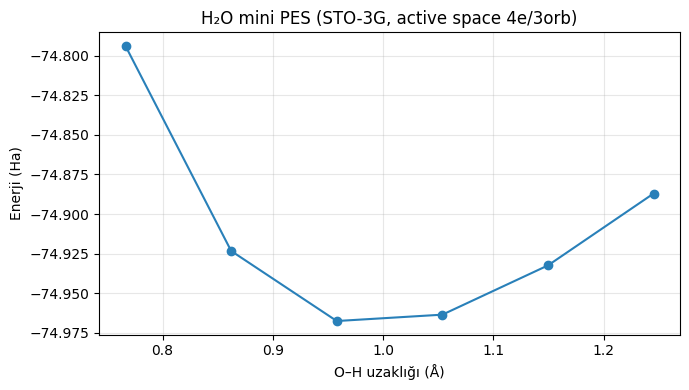


Minimum (tarama): r≈0.958 Å, E=-74.967450 Ha


In [ ]:
def h2o_energy_at_scale(scale, mapper_factory=ParityMapper):
    """OH mesafesini scale ile çarp, active space exact enerji döndür."""
    th = np.deg2rad(104.5 / 2)
    r = 0.958 * scale
    hx, hz = r * np.sin(th), r * np.cos(th)
    atom = f"O 0 0 0; H {hx:.6f} 0 {hz:.6f}; H {-hx:.6f} 0 {hz:.6f}"
    drv = PySCFDriver(atom=atom, basis="sto3g", charge=0, spin=0, unit=DistanceUnit.ANGSTROM)
    full = drv.run()
    red = ActiveSpaceTransformer(4, 3).transform(FreezeCoreTransformer().transform(full))
    mapper = ParityMapper(num_particles=red.num_particles)
    res = GroundStateEigensolver(mapper, NumPyMinimumEigensolver()).solve(red)
    return float(res.total_energies[0])

scales = np.linspace(0.8, 1.3, 6)
energies = []
print("PES taraması (active-space exact)...")
for s in scales:
    e = h2o_energy_at_scale(s)
    energies.append(e)
    print(f"  scale={s:.2f}  r(OH)={0.958*s:.3f} A  E={e:.6f} Ha")

plt.figure(figsize=(7, 4))
plt.plot(0.958 * scales, energies, "o-", color="#2980b9")
plt.xlabel("O–H uzaklığı (Å)")
plt.ylabel("Enerji (Ha)")
plt.title("H₂O mini PES (STO-3G, active space 4e/3orb)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

i_min = int(np.argmin(energies))
print(f"\nMinimum (tarama): r≈{0.958*scales[i_min]:.3f} Å, E={energies[i_min]:.6f} Ha")


## 9. Sonuçların Yorumu

| Kavram | Bu notebook’ta |
|--------|----------------|
| Molekül tanımı | XYZ / iç koordinat → PySCFDriver |
| Hamiltonyen | 2. kuantizasyon + integral |
| Boyut indirgeme | FreezeCore + ActiveSpace |
| Qubit map | ParityMapper (JW alternatifi) |
| Klasik referans | NumPyMinimumEigensolver |
| Kuantum tahmin | VQE (TwoLocal / UCCSD) |
| “Tahmin” | Enerji + basit PES taraması |

**Kimyasal doğruluk:** 1 mHa ≈ 0.027 eV. Active space + STO-3G ile gerçek deneysel H₂O enerjisine birebir yaklaşmayız; amaç **yöntem pipeline’ı**.

**Sınırlar:**  
- Daha iyi basis (6-31G, cc-pVDZ) → daha çok orbital  
- Gerçek donanım → gürültü, ölçüm overhead  
- Excited states → farklı algoritmalar (QEOM, VQD)

### Öğrenci ödevleri
1. Active space’i (6e, 4orb) yapıp qubit / süre değişimini ölçün  
2. Jordan–Wigner vs Parity qubit sayısını karşılaştırın  
3. H₂ için bağ uzunluğu taraması (0.5–1.5 Å) çizin  
4. `RUN_UCCSD=True` ile TwoLocal farkını yazın  

---
**Hazırlayan:** Joseph Volkan Ozcan  
**Stack:** Qiskit Nature · PySCF · VQE · Aer  
**Colab · 2026**
